<a href="https://www.kaggle.com/code/lukaspanos/titanic-survival-prediction-log-reg-rfc?scriptVersionId=344265060" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

pd.set_option('display.max_columns', None)
print(train.shape)
print(train.isnull().sum())

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [2]:
train.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
# Overall survival rate
print(f"Overall survival rate: {train['Survived'].mean():.2%}")

# By sex
print(train.groupby('Sex')['Survived'].mean())

# By passenger class
print(train.groupby('Pclass')['Survived'].mean())

# By both
print(train.groupby(['Sex', 'Pclass'])['Survived'].mean())

Overall survival rate: 38.38%
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64


The numbers tell a story:

* Sex is overwhelming: 74% of women survived vs 19% of men — "women and children first".
* Class was life or death: 63% of 1st class survived vs 24% of 3rd class.
* The combination is extreme: 1st class women survived at 97%; 3rd class men at 13.5%.
* Baseline to remember: 38.38% overall survival means a dumb model predicting "everyone dies" scores 61.6% accuracy. Our model has to beat that to be half decent.

In [4]:
# Age (177 missing, ~20%) — too many to drop rows.
# Impute with median by passenger class — 1st class passengers were older on average
train['Age'] = train.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked (2 missing) — just use the mode
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Cabin (687 missing, 77%) — too sparse to use directly,
# BUT whether a cabin was recorded at all is signal (recorded = likely wealthier)
# Thus, we can create a new column which indicates if a person even has a cabin recorded, and drop the Cabin column.
train['HasCabin'] = train['Cabin'].notnull().astype(int)
train.drop(columns=['Cabin'], inplace=True)

print(train.isnull().sum().sum())

0


In [5]:
print(train.groupby('HasCabin')['Survived'].mean())

HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


In [6]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)

# Family features from SibSp (siblings/spouses) + Parch (parents/children)
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)

train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.')

# Group the rare ones
train['Title'] = train['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Countess',
                                          'Sir', 'Jonkheer', 'Lady', 'Capt', 'Don', 'Dona'], 'Rare')
train['Title'] = train['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print(train.groupby('Title')['Survived'].mean())

train = pd.get_dummies(train, columns=['Title'], drop_first=True)

# Drop what we can't use directly
train.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

Title
Master    0.575000
Miss      0.702703
Mr        0.156673
Mrs       0.793651
Rare      0.347826
Name: Survived, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X = train.drop(columns=['Survived'])
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1:        {f1_score(y_test, y_pred):.3f}")

Accuracy:  0.821
Precision: 0.794
Recall:    0.725
F1:        0.758


Two things in there:

* stratify=y — makes the split preserve the 38/62 class balance in both train and test. Without it, a random split could give us a test set with a skewed survival rate, distorting our metrics. Classification habit worth building now.
* max_iter=1000 — logistic regression is solved iteratively; default 100 iterations sometimes isn't enough to converge, and unscaled features like Fare make it slower.

What the metrics mean here, concretely:

* Accuracy — fraction of all predictions that were right
* Precision — of everyone we predicted survived, how many actually did. Punishes false alarms
* Recall — of everyone who actually survived, how many we caught. Punishes misses
* F1 — harmonic mean of the two, useful single number when we care about both

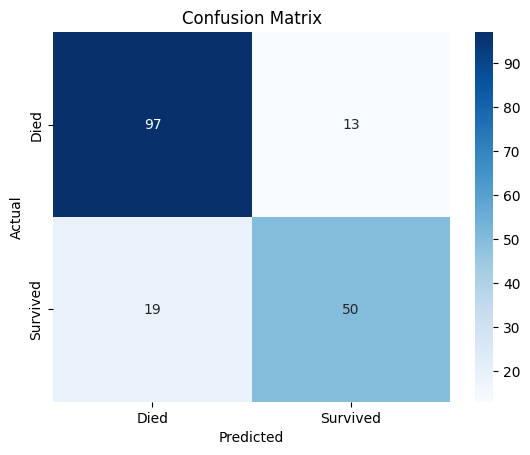

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

6 correctly predicted deaths, 48 correctly predicted survivals — 144/179 right
14 false positives — predicted survived, actually died
21 false negatives — predicted died, actually survived

In [9]:
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print(coefs)

Title_Mr     -2.031913
Title_Rare   -0.957284
Pclass       -0.791106
Embarked_S   -0.294141
IsAlone      -0.272290
FamilySize   -0.258418
Title_Miss   -0.214474
SibSp        -0.189024
Parch        -0.075530
Age          -0.038062
Fare          0.002363
Embarked_Q    0.288053
Title_Mrs     0.577000
Sex           0.816559
HasCabin      0.892931
dtype: float64


In [10]:
y_proba = logreg.predict_proba(X_test)[:, 1]  # probability of survival

# Default threshold is 0.5 — lower it and recall rises, precision falls
y_pred_low = (y_proba >= 0.35).astype(int)
print(f"Precision: {precision_score(y_test, y_pred_low):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_low):.3f}")

Precision: 0.750
Recall:    0.826


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = train.drop(columns=['Survived'])
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Refit logreg on the new features for a fair comparison
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
print(f"LogReg accuracy:  {accuracy_score(y_test, logreg.predict(X_test)):.3f}")

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
print(f"RF accuracy:      {accuracy_score(y_test, rf.predict(X_test)):.3f}")

# CV for the trustworthy comparison — you know why by now
print(f"LogReg CV: {cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5, scoring='accuracy').mean():.3f}")
print(f"RF CV:     {cross_val_score(RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42), X, y, cv=5, scoring='accuracy').mean():.3f}")

LogReg accuracy:  0.821
RF accuracy:      0.810
LogReg CV: 0.822
RF CV:     0.827


Random Forest barely edges out logistic regression (0.827 vs 0.822 CV), and on the single split it actually loses. Compare that to House Prices where XGBoost clearly won. Why the difference is worth internalizing:

Small data — 891 rows doesn't give trees much room to find complex patterns without overfitting
The problem is nearly linear — survival is mostly additive effects: being female helps, high class helps, being a boy helps. Titles gave the linear model exactly the piece it was missing. There isn't much non-linear interaction left to exploit
Lesson: model complexity should match problem complexity. On small, mostly-linear tabular problems, logistic regression is competitive, faster, and interpretable

In [12]:
test_ids = test['PassengerId']

# Title FIRST (needs Name), same grouping as train
test['Title'] = test['Name'].str.extract(r' ([A-Za-z]+)\.')
test['Title'] = test['Title'].replace(['Dr', 'Rev', 'Col', 'Major', 'Countess',
                                        'Sir', 'Jonkheer', 'Lady', 'Capt', 'Don', 'Dona'], 'Rare')
test['Title'] = test['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# Same cleaning as train (match whichever Age imputation you used!)
test['Age'] = test.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0])
test['Fare'] = test['Fare'].fillna(test['Fare'].median())   # test-only gap
test['HasCabin'] = test['Cabin'].notnull().astype(int)

test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

test = pd.get_dummies(test, columns=['Embarked', 'Title'], drop_first=True)
test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Column alignment — you know this one
test = test.reindex(columns=X.columns, fill_value=0)
print(test.isnull().sum().sum())  # must be 0

# Predict with the CV winner — retrain on ALL train data first
rf_final = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf_final.fit(X, y)

submission = pd.DataFrame({'PassengerId': test_ids, 'Survived': rf_final.predict(test)})
submission.to_csv('submission.csv', index=False)
print(submission.head())

0
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
